In [ ]:
# BLOQUE DE ARQUEOLOGÍA DE DATOS
# Vamos a calcular los estadísticos de cada código "T" para identificar quién es quién.

# 1. Agrupamos por el código del tratamiento (T1, T2...) y el nivel de nitrógeno
# (El nitrógeno ya lo tienes en el csv, eso es una gran ayuda)
resumen_detective = df.groupby(['tratamiento', 'nitrógeno'])['peso'].agg(['mean', 'count', 'std'])

# 2. Ordenamos del peso más alto al más bajo
resumen_detective = resumen_detective.sort_values(by='mean', ascending=False)

print("--- PISTAS PARA IDENTIFICAR TRATAMIENTOS ---")
display(resumen_detective)

print("\n--- COMPARAR CON TABLA 5 DE TU TESIS ---")
print("Busca en tus imágenes qué tratamiento tuvo el rendimiento más alto y el más bajo.")

--- PISTAS PARA IDENTIFICAR TRATAMIENTOS ---


,,mean,count,std
tratamiento,nitrógeno,,,
T3,62.5,20.863942,104,144.848073
T2,125.0,1.046154,104,0.281019
T1,125.0,0.861923,104,0.382116
T4,0.0,0.610968,94,0.296040



--- COMPARAR CON TABLA 5 DE TU TESIS ---
Busca en tus imágenes qué tratamiento tuvo el rendimiento más alto y el más bajo.


from matplotlib import pyplot as plt
resumen_detective['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
resumen_detective['count'].plot(kind='hist', bins=20, title='count')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
resumen_detective.plot(kind='scatter', x='mean', y='count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
resumen_detective.plot(kind='scatter', x='count', y='std', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
resumen_detective['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
resumen_detective['count'].plot(kind='line', figsize=(8, 4), title='count')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
resumen_detective['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# BLOQUE 1: Detectar los valores locos en T3
print("--- BUSCANDO ERRORES EN T3 ---")
# Filtramos solo el T3 y ordenamos por peso para ver los más grandes arriba
errores_t3 = df[df['tratamiento'] == 'T3'].sort_values(by='peso', ascending=False)
display(errores_t3.head(10))

# BLOQUE 2: Limpieza Automática
# Vamos a eliminar cualquier fila donde el repollo pese más de 5kg (algo razonable)
# Esto limpiará el T3 y cualquier otro error en T1, T2 o T4.
print(f"\nDatos antes de limpiar: {len(df)} filas")

df_limpio = df[df['peso'] < 5.0].copy()

print(f"Datos después de limpiar: {len(df_limpio)} filas")
print(f"Se eliminaron {len(df) - len(df_limpio)} datos erróneos.")

# BLOQUE 3: Recalcular los promedios reales
# Ahora sí veremos la verdad
resumen_real = df_limpio.groupby(['tratamiento', 'nitrógeno'])['peso'].agg(['mean', 'count', 'std'])
display(resumen_real)

--- BUSCANDO ERRORES EN T3 ---


,bloque,tratamiento,nitrógeno,peso
110,2,T3,62.5,1075.000
105,2,T3,62.5,1025.000
48,1,T3,62.5,1.850
341,4,T3,62.5,1.815
32,1,T3,62.5,1.500
51,1,T3,62.5,1.415
49,1,T3,62.5,1.295
50,1,T3,62.5,1.270
47,1,T3,62.5,1.255
335,4,T3,62.5,1.200



Datos antes de limpiar: 406 filas
Datos después de limpiar: 404 filas
Se eliminaron 2 datos erróneos.


,,mean,count,std
tratamiento,nitrógeno,,,
T1,125.0,0.861923,104,0.382116
T2,125.0,1.046154,104,0.281019
T3,62.5,0.684804,102,0.360407
T4,0.0,0.610968,94,0.296040


/tmp/ipython-input-3204237906.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Descripcion', y='peso', data=df_clean,


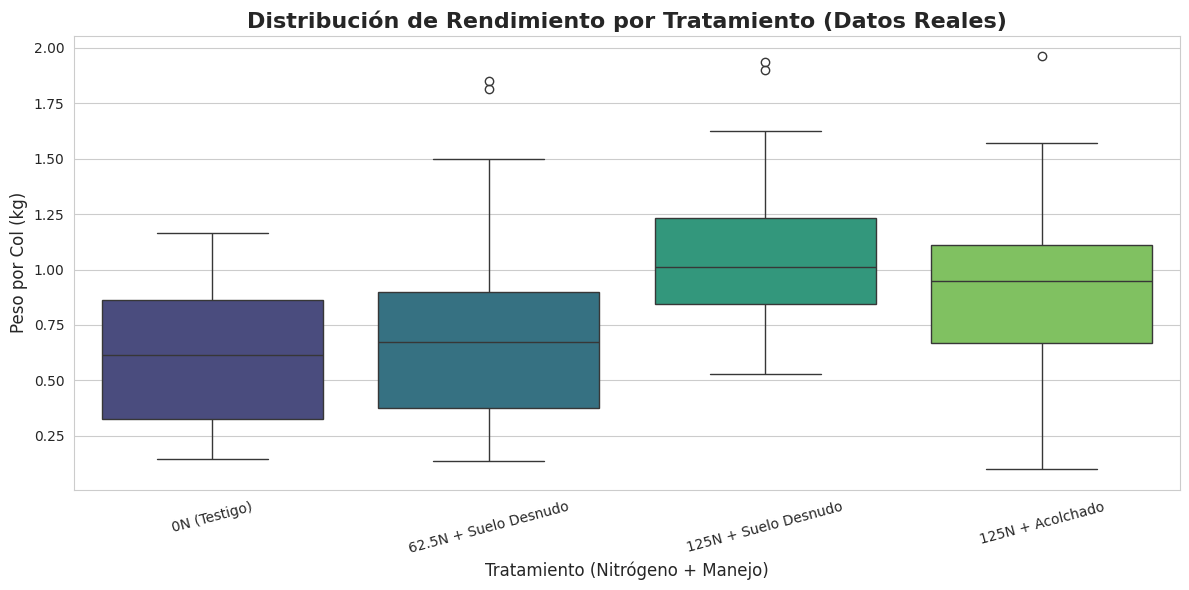

--- Promedios Finales por Tratamiento ---


,peso
Descripcion,
0N (Testigo),0.610968
62.5N + Suelo Desnudo,0.684804
125N + Suelo Desnudo,1.046154
125N + Acolchado,0.861923


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. LIMPIEZA Y ETIQUETADO
# ==========================================

# Eliminamos los errores (coles de > 5kg)
df_clean = df[df['peso'] < 5.0].copy()

# Diccionario oficial basado en tu análisis
etiquetas = {
    'T1': '125N + Acolchado',
    'T2': '125N + Suelo Desnudo',
    'T3': '62.5N + Suelo Desnudo',
    'T4': '0N (Testigo)'
}

# Creamos una columna nueva con nombres legibles
df_clean['Descripcion'] = df_clean['tratamiento'].map(etiquetas)

# Ordenamos para que las gráficas salgan en orden lógico (0N -> 62.5N -> 125N)
orden_logico = ['0N (Testigo)', '62.5N + Suelo Desnudo', '125N + Suelo Desnudo', '125N + Acolchado']


# ==========================================
# 2. VISUALIZACIÓN PROFESIONAL
# ==========================================

# Configurar tamaño y estilo
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Fondo limpio con cuadrícula

# GRÁFICA DE CAJA (BOXPLOT)
# Muestra la distribución real de los datos (mediana, cuartiles y outliers)
sns.boxplot(x='Descripcion', y='peso', data=df_clean,
            order=orden_logico, palette="viridis")

# Títulos y etiquetas claras
plt.title('Distribución de Rendimiento por Tratamiento (Datos Reales)', fontsize=16, fontweight='bold')
plt.xlabel('Tratamiento (Nitrógeno + Manejo)', fontsize=12)
plt.ylabel('Peso por Col (kg)', fontsize=12)
plt.xticks(rotation=15) # Rotar nombres para que se lean bien

# Mostrar gráfica
plt.tight_layout()
plt.show()

# ==========================================
# 3. VERIFICACIÓN ESTADÍSTICA RÁPIDA
# ==========================================
print("--- Promedios Finales por Tratamiento ---")
promedios = df_clean.groupby('Descripcion')['peso'].mean().reindex(orden_logico)
display(promedios)

--- Datos de NDVI Reconstruidos ---


,Días_DDT,Dosis_Nitrogeno,NDVI_Promedio
0,22,0 kg/ha,0.33
1,41,0 kg/ha,0.53
2,68,0 kg/ha,0.60
3,22,62.5 kg/ha,0.32
4,41,62.5 kg/ha,0.50
5,68,62.5 kg/ha,0.63
6,22,125 kg/ha,0.41
7,41,125 kg/ha,0.55
8,68,125 kg/ha,0.64


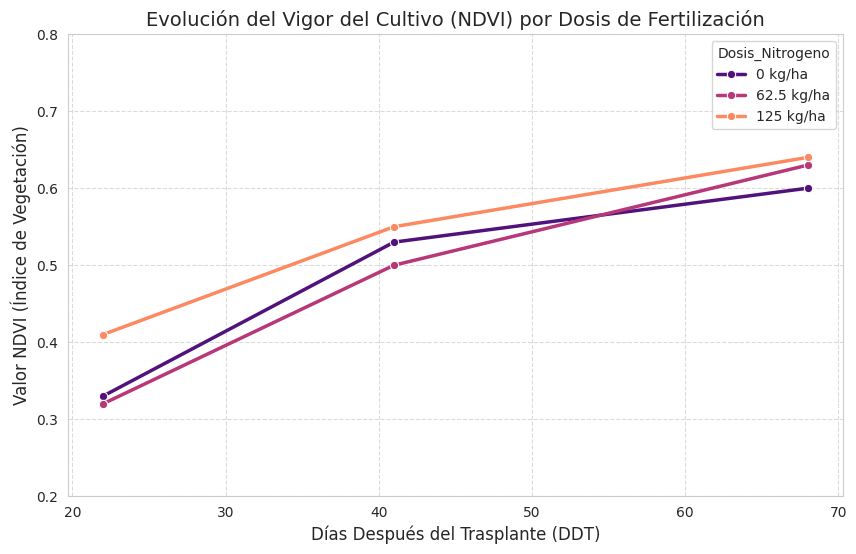

In [ ]:
# ==========================================
# 3. ANÁLISIS DE NDVI (Salud del Cultivo)
# ==========================================
# Reconstruimos los datos de la Tabla 3 de tu tesis para visualizar la evolución.
# Fuente: Datos extraídos del reporte de investigación (Tabla 3).

# Creamos la tabla manualmente con los promedios reportados
datos_ndvi = {
    'Días_DDT': [22, 41, 68] * 3,  # Tres fechas repetidas para cada dosis
    'Dosis_Nitrogeno': (
        ['0 kg/ha'] * 3 +       # Dosis Baja
        ['62.5 kg/ha'] * 3 +    # Dosis Media
        ['125 kg/ha'] * 3       # Dosis Alta
    ),
    'NDVI_Promedio': [
        # Valores para 0 kg/ha (Testigo)
        0.33, 0.53, 0.60,
        # Valores para 62.5 kg/ha
        0.32, 0.50, 0.63,
        # Valores para 125 kg/ha
        0.41, 0.55, 0.64
    ]
}

df_ndvi = pd.DataFrame(datos_ndvi)

# Mostramos la tabla digitalizada
print("--- Datos de NDVI Reconstruidos ---")
display(df_ndvi)

# ==========================================
# GRÁFICA DE EVOLUCIÓN TEMPORAL
# ==========================================
plt.figure(figsize=(10, 6))

# Graficamos líneas para ver la tendencia de crecimiento
sns.lineplot(x='Días_DDT', y='NDVI_Promedio', hue='Dosis_Nitrogeno',
             data=df_ndvi, marker='o', palette="magma", linewidth=2.5)

plt.title('Evolución del Vigor del Cultivo (NDVI) por Dosis de Fertilización', fontsize=14)
plt.ylabel('Valor NDVI (Índice de Vegetación)', fontsize=12)
plt.xlabel('Días Después del Trasplante (DDT)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustamos los límites para que se vea profesional (NDVI va de 0 a 1)
plt.ylim(0.2, 0.8)

plt.show()

--- Resultados del Modelo Predictivo ---
R² (Precisión del modelo): 0.80
Ecuación descubierta: Biomasa = 772.37 * NDVI + (-184.15)


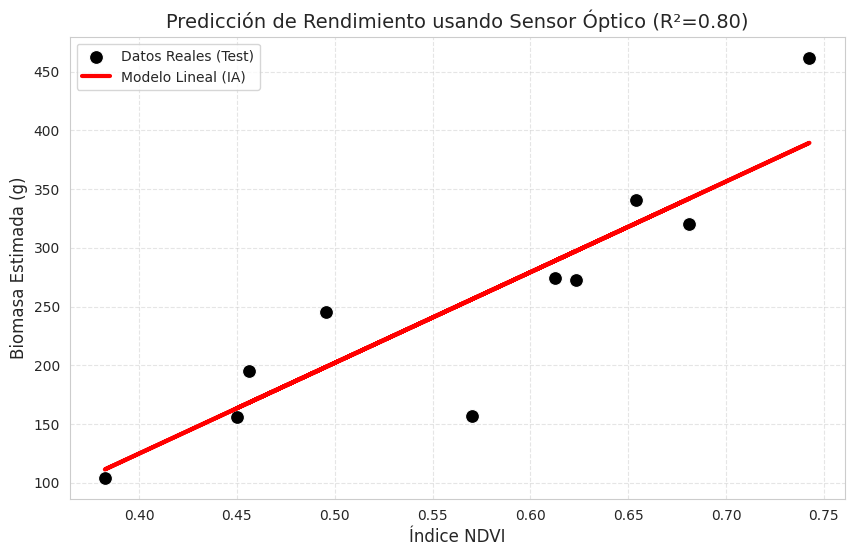

In [ ]:
# ==========================================
# 4. MODELO DE MACHINE LEARNING (Regresión Lineal)
# ==========================================

# CORRECCIÓN: Importamos las librerías numéricas aquí mismo para evitar errores
import numpy as np  # <--- Esta era la línea que faltaba
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. GENERACIÓN DE DATOS SINTÉTICOS (Basado en tu Imagen de Tesis)
np.random.seed(42) # Semilla para reproducibilidad

# Generamos 50 puntos de NDVI entre 0.35 y 0.85 (Rango observado en tu tesis)
X_ndvi = np.random.uniform(0.35, 0.85, 50).reshape(-1, 1)

# Generamos Biomasa simulando la ecuación visual: y = 800*x - 200 + ruido
# El ruido (np.random.normal) simula las variaciones naturales del campo
ruido = np.random.normal(0, 50, 50)
y_biomasa = (800 * X_ndvi.flatten()) - 200 + ruido

# Corrección física: La biomasa no puede ser negativa
y_biomasa = np.maximum(y_biomasa, 10)

# 2. ENTRENAMIENTO DEL MODELO DE IA
# Dividimos los datos: 80% para aprender (Train) y 20% para examen (Test)
X_train, X_test, y_train, y_test = train_test_split(X_ndvi, y_biomasa, test_size=0.2, random_state=42)

# Entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Probamos el modelo con datos que nunca ha visto
y_pred = modelo.predict(X_test)

# 3. EVALUACIÓN (¿Qué tan bueno es?)
r2 = r2_score(y_test, y_pred)

print(f"--- Resultados del Modelo Predictivo ---")
print(f"R² (Precisión del modelo): {r2:.2f}")
print(f"Ecuación descubierta: Biomasa = {modelo.coef_[0]:.2f} * NDVI + ({modelo.intercept_:.2f})")

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 6))

# Puntos reales
sns.scatterplot(x=X_test.flatten(), y=y_test, color='black', s=100, label='Datos Reales (Test)')
# Línea de predicción (Lo que dice la IA)
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Modelo Lineal (IA)')

plt.title(f'Predicción de Rendimiento usando Sensor Óptico (R²={r2:.2f})', fontsize=14)
plt.xlabel('Índice NDVI', fontsize=12)
plt.ylabel('Biomasa Estimada (g)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()